# 05: Geography: Which Regions Have the Most Delivery Problems?

Brazil is a huge country and most sellers are concentrated in the Southeast
(SP/RJ/MG). This notebook checks whether that creates a measurable delivery
disadvantage for customers elsewhere.

In [6]:
import os
for folder in ["../data/raw", "../data/interim", "../data/processed",
                "../reports/figures", "../notebooks", "../src"]:
    os.makedirs(folder, exist_ok=True)
print("All folders confirmed.")

All folders confirmed.


In [7]:
import sys
!{sys.executable} -m pip install plotly

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.1 MB 7.2 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/9.1 MB 4.4 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.1 MB 4.6 MB/s eta 0:00:02
   ---------------- ----------------------- 3.7/9.1 MB 4.4 MB/s eta 0:00:02
   ---------------------- ----------------- 5.0/9.1 MB 4.7 MB/s eta 0:00:01
   --------------------------- ------------ 6.3/9.1 MB 5.0 MB/s eta 0:00:01
   --------------------------------- ------ 7.6/9.1 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------  8.9/9.1 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 5.3 MB/s eta 0:00:00


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110

delivered = pd.read_csv("../data/processed/delivered_orders.csv")
delivered = delivered.dropna(subset=["delivery_delay_days"])

## Q5: State-level delivery performance

Group by `customer_state`, filter to states with at least 50 delivered orders
(some states have very few orders and would be noisy), and sort by % of orders
delivered late.

In [9]:
state_delivery = (
    delivered.groupby("customer_state")
    .agg(
        avg_delay=("delivery_delay_days", "mean"),
        pct_late=("is_late", "mean"),
        avg_review=("review_score", "mean"),
        n_orders=("order_id", "count")
    )
    .query("n_orders >= 50")
    .sort_values("pct_late", ascending=False)
)
print(state_delivery)

                avg_delay  pct_late  avg_review  n_orders
customer_state                                           
AL              -8.707809  0.214106    3.857868       397
MA              -9.571827  0.174338    3.834270       717
SE             -10.020896  0.152239    3.907186       335
PI             -11.306723  0.138655    3.993631       476
CE             -10.804535  0.137608    3.939513      1279
BA             -10.794533  0.121622    3.930319      3256
RJ             -11.761215  0.121053    3.964458     12350
PA             -14.066596  0.112051    3.905681       946
ES             -10.496241  0.107268    4.080752      1995
PB             -13.261122  0.104449    4.076172       517
TO             -12.131387  0.098540    4.153846       274
MS             -11.052782  0.097004    4.158798       701
PE             -13.293785  0.096045    4.082331      1593
RN             -13.649789  0.092827    4.150743       474
SC             -11.503384  0.082064    4.132992      3546
GO            

**Expect a strong geography effect**: North/Northeast states (far from the
Southeast seller hubs) should show meaningfully higher late-delivery rates and
lower average review scores than SP/RJ/MG/PR. Name the worst 3 states with
actual numbers in your report — specificity is what makes this finding land.

## Chart: worst states by % late (simple, zero-setup version)


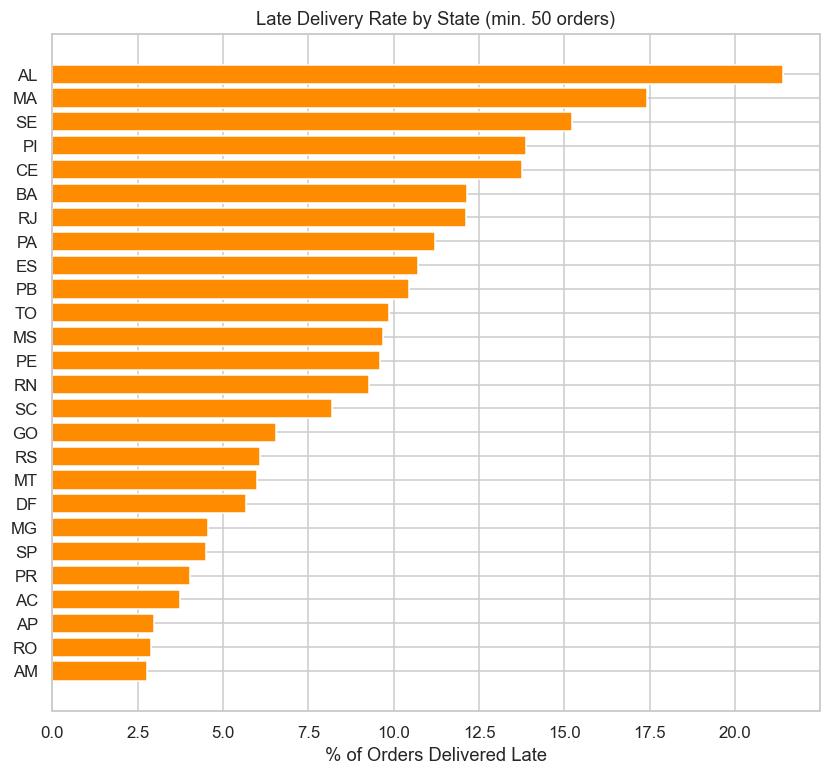

In [10]:
fig, ax = plt.subplots(figsize=(9, 8))
worst_states = state_delivery.sort_values("pct_late", ascending=True)
ax.barh(worst_states.index, worst_states["pct_late"] * 100, color="darkorange")
ax.set_xlabel("% of Orders Delivered Late")
ax.set_title("Late Delivery Rate by State (min. 50 orders)")
plt.savefig("../reports/figures/06b_state_delay_bar.png", bbox_inches="tight")
plt.show()

## Chart: choropleth map 

Geography questions are usually clearer as a map than a bar chart. This needs a
Brazil state GeoJSON — the property key that matches state abbreviations
(`sigla` here) can vary between GeoJSON sources, so always open the file once in
a browser and check the `properties` object on one feature before running the
full chart. This is the most common failure point in choropleths.

In [11]:
import plotly.express as px

geojson_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"

fig = px.choropleth(
    state_delivery.reset_index(),
    geojson=geojson_url,
    locations="customer_state",
    featureidkey="properties.sigla",
    color="pct_late",
    color_continuous_scale="Reds",
    scope="south america",
    title="% of Orders Delivered Late, by State"
)
fig.update_geos(fitbounds="locations", visible=False)
fig.write_html("../reports/figures/06_state_delay_map.html")
fig.show()